# Customer Churn Prediction & Retention Analytics

## Project Overview

Customer churn is a major challenge for telecommunications companies.
This project analyzes customer behavior and develops machine learning
models to identify customers who are likely to leave the company.

The project combines exploratory data analysis, data preprocessing,
feature engineering, machine learning, model evaluation, and business
insights to support customer retention strategies.

### Business Objective

The primary objective is to:

- Understand the factors associated with customer churn.
- Explore customer behavior and service usage patterns.
- Build machine learning models to predict customer churn.
- Identify high-risk customers.
- Provide actionable recommendations that can support customer retention.

### Machine Learning Problem

This is a binary classification problem.

The target variable is:

- `0` → Customer stays
- `1` → Customer churns

## Executive Summary

Customer churn is a significant challenge for telecommunications companies,
as losing existing customers can negatively impact revenue and increase
customer acquisition costs.

This project analyzes customer data to identify factors associated with
churn and develops machine learning models to predict customers who are
at risk of leaving.

The analysis covers data cleaning, exploratory data analysis, feature
engineering, machine learning, model evaluation, hyperparameter tuning,
and customer risk segmentation.

The final solution provides both predictive insights and actionable
recommendations that can support customer retention strategies.

## Project Workflow

The project follows an end-to-end data science workflow:

**Data Collection**
→ **Data Cleaning**
→ **Exploratory Data Analysis**
→ **Feature Engineering**
→ **Model Development**
→ **Model Evaluation**
→ **Hyperparameter Tuning**
→ **Customer Risk Prediction**
→ **Business Recommendations**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Loading

In this section, we load the customer churn dataset into a Pandas DataFrame.

A DataFrame is a table-like structure provided by Pandas that allows us
to inspect, manipulate, and analyze structured data.

In [2]:
# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Dataset Dimensions

Let's check the number of rows and columns in the dataset.

This helps us understand the overall size of the data before beginning
the analysis.

In [3]:
df.shape

(7043, 21)

## 3. Dataset Features

The dataset contains demographic information, customer services,
account information, billing information, and the customer's churn status.

Let's examine all available variables.

In [4]:
# Display all column names
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

## 4. Data Structure and Data Types

The `info()` method provides information about:

- The number of records
- Column names
- Data types
- Non-null values
- Potential missing values

This is one of the first checks we perform when working with a new dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 5. Statistical Summary

We use descriptive statistics to understand the distribution of numerical
variables in the dataset.

This includes measures such as:

- Count
- Mean
- Standard deviation
- Minimum value
- Maximum value
- Quartiles

In [6]:
# Generate descriptive statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 6. Missing Value Analysis

Missing values occur when information is not available for a particular
customer or variable.

Identifying missing values is an important part of data preparation because
machine learning models generally cannot work directly with missing data.

In [7]:
# Check the number of missing values in each column
missing_values = df.isnull().sum()

missing_values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 7. Checking for Invalid or Empty Values

Some datasets contain empty strings instead of standard missing values.

We will check the `TotalCharges` column for empty values before converting
it into a numerical data type.


In [8]:
# Count empty strings in TotalCharges
(df["TotalCharges"] == " ").sum()

np.int64(11)

## 8. Duplicate Records

Duplicate records can distort analysis and machine learning results.

We will check whether the dataset contains duplicate rows.

In [9]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

## 9. Creating a Working Copy

Before cleaning the dataset, we create a copy of the original DataFrame.

This allows us to preserve the original data and perform all cleaning
operations on a separate working dataset.

In [10]:
# Create a copy of the original dataset
data = df.copy()

print("Working dataset created successfully.")

Working dataset created successfully.


## 10. Removing Unnecessary Features

The `customerID` column is a unique identifier for each customer.

Since it does not describe customer behavior or characteristics, it will
not provide meaningful information for our machine learning models.

We will therefore remove it from the analysis.

In [11]:
# Remove customer ID
data.drop("customerID", axis=1, inplace=True)

# Confirm the column was removed
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 11. Cleaning the TotalCharges Column

The `TotalCharges` column contains some blank values represented as empty
strings.

Since TotalCharges represents a monetary amount, it should be stored as a
numeric variable.

We will:

1. Replace blank strings with missing values.
2. Convert the column to numeric.
3. Check the result.

In [12]:
# Replace blank strings with NaN
data["TotalCharges"] = data["TotalCharges"].replace(" ", np.nan)

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"])

# Check the data type
data["TotalCharges"].dtype

dtype('float64')

## 12. Handling Missing Values

After converting `TotalCharges` to a numeric variable, the previously
hidden blank values are now recognized as missing values.

Only a very small number of records are affected, so we will remove those
records rather than introducing artificial values through imputation.

In [13]:
# Remove rows with missing TotalCharges
data.dropna(subset=["TotalCharges"], inplace=True)

# Check remaining missing values
data.isnull().sum().sum()

np.int64(0)

## 13. Encoding the Target Variable

The `Churn` column is our target variable.

It currently contains two categorical values:

- `Yes` → Customer churned
- `No` → Customer stayed

For machine learning, we will encode these values numerically:

- `0` → Customer stayed
- `1` → Customer churned

In [14]:
# Convert Churn into a binary numerical variable
data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})

# Check the result
data["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## 14. Final Data Quality Check

After cleaning the dataset, we perform a final quality check to confirm
that:

- Missing values have been handled.
- Duplicate records are absent.
- Numerical columns have the correct data types.
- The target variable has been encoded correctly.

In [15]:
# Check dataset structure

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [16]:
# Check for missing values

data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
# Check duplicate rows

data.duplicated().sum()

np.int64(22)

In [18]:
data.shape

(7032, 20)

## 15. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to investigate patterns,
relationships, and trends within the dataset.

We begin by examining the overall distribution of customer churn.

In [19]:
# Count customers who stayed and customers who churned
churn_counts = data["Churn"].value_counts()

# Display the counts
churn_counts

Churn
0    5163
1    1869
Name: count, dtype: int64

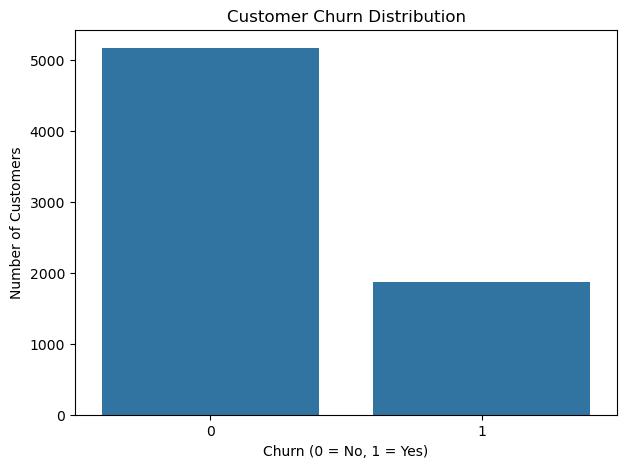

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Churn", data=data)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [21]:
# Calculate churn percentage
churn_rate = data["Churn"].mean() * 100

print(f"Customer churn rate: {churn_rate:.2f}%")

Customer churn rate: 26.58%


## 16. Churn by Gender

We examine customer churn across gender categories to determine whether
there is a noticeable difference in churn behavior between male and female
customers.

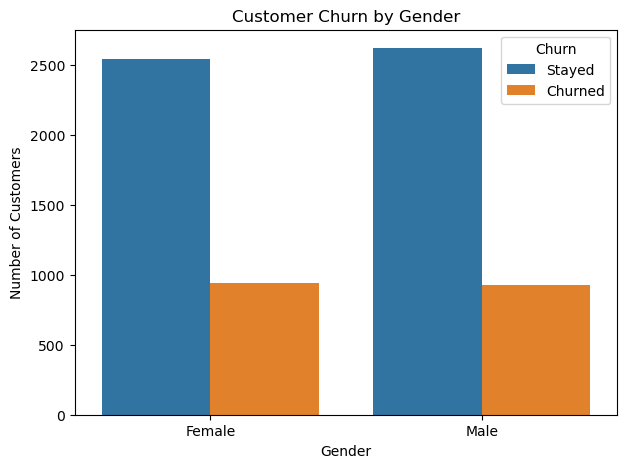

In [22]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x="gender",
    hue="Churn",
    data=data
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.show()

## 17. Churn by Contract Type

Contract type may influence customer retention.

We compare churn across:

- Month-to-month
- One year
- Two year

This helps us determine whether customers with longer-term contracts
display different churn behavior.

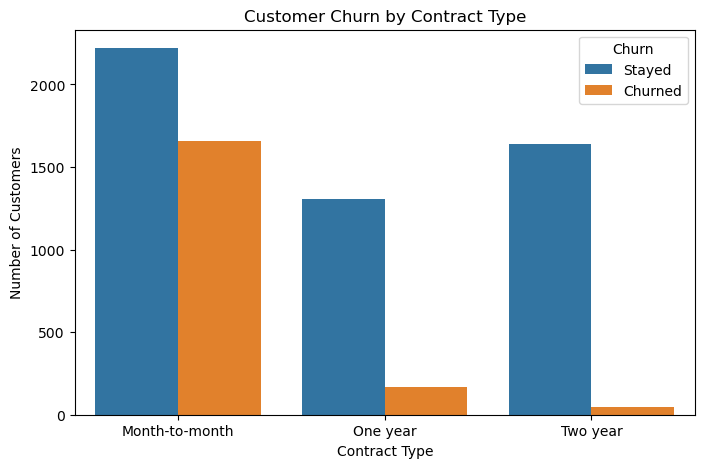

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=data
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.show()

## 18. Churn by Customer Tenure

Tenure represents the number of months a customer has been with the company.

We analyze tenure to determine whether newer or long-term customers are
more likely to churn.

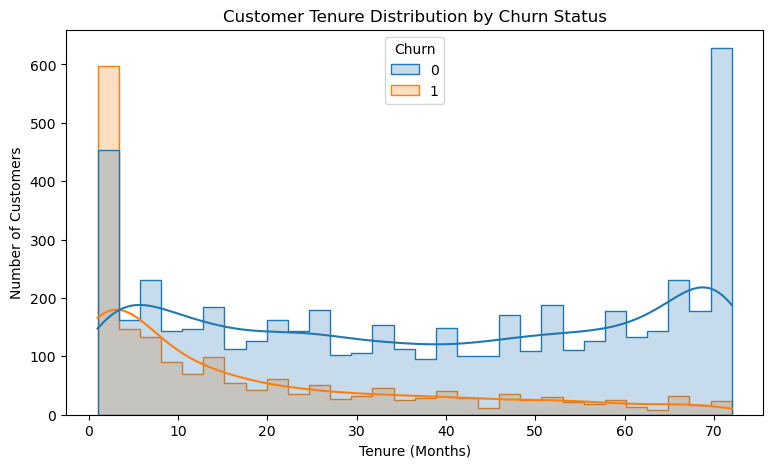

In [24]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=data,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Customer Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

## 19. Monthly Charges and Customer Churn

MonthlyCharges represents the amount a customer is charged each month.

We compare monthly charges between customers who stayed and customers who
churned to identify potential pricing-related patterns.

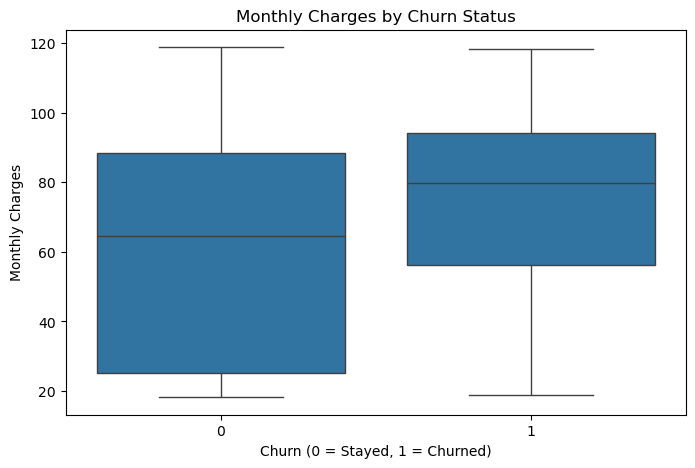

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=data
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Monthly Charges")

plt.show()

## 20. Churn by Internet Service

Different internet service types may be associated with different levels
of customer churn.

We compare churn across the available internet service categories.

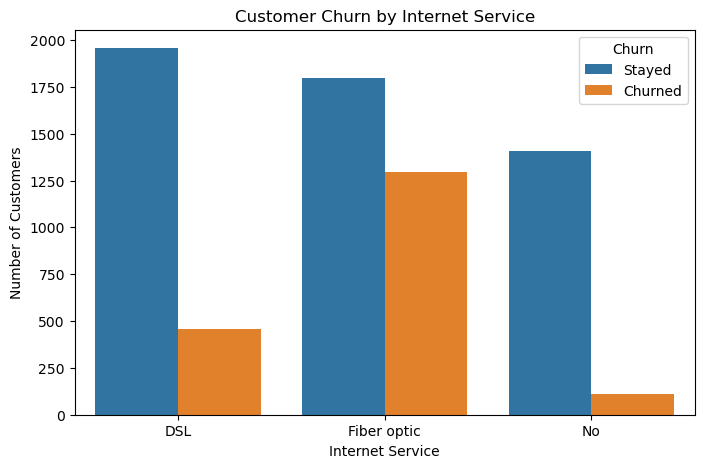

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=data
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.show()

## 21. Churn by Payment Method

We analyze customer churn across different payment methods to determine
whether payment behavior is associated with customer retention.

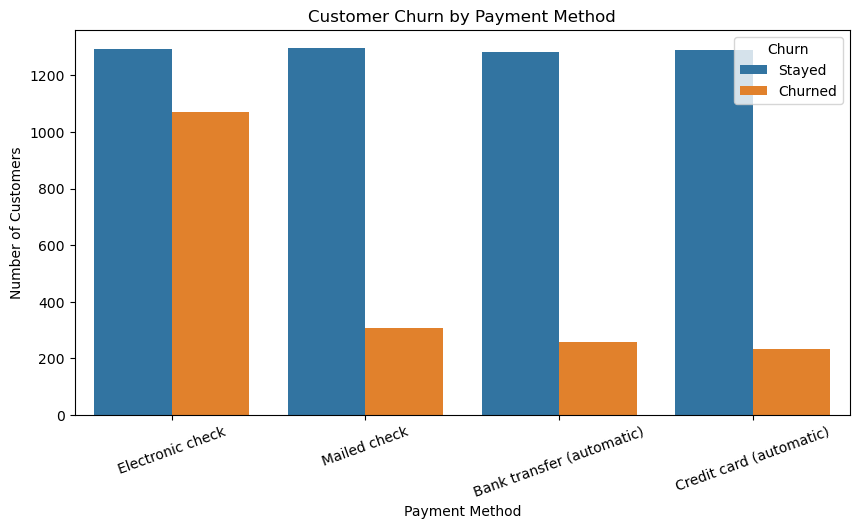

In [27]:
plt.figure(figsize=(10, 5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=data
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.show()

 ## 22. Churn and Technical Support

Customer support services may influence customer satisfaction and retention.

We compare churn rates between customers who have technical support and
those who do not.

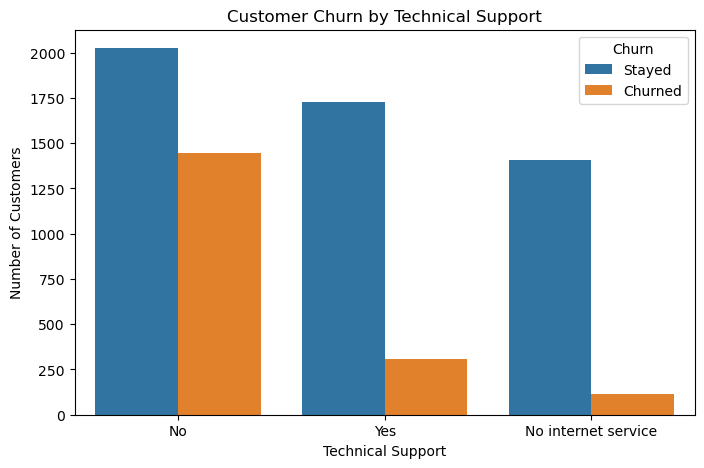

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="TechSupport",
    hue="Churn",
    data=data
)

plt.title("Customer Churn by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["Stayed", "Churned"])

plt.show()

## 23. Churn Rate by Contract Type

Customer counts alone can be misleading because different contract types
contain different numbers of customers.

We therefore calculate the percentage of customers who churned within
each contract category.

In [29]:
# Calculate churn rate by contract type
contract_churn = (
    data.groupby("Contract")["Churn"]
    .mean()
    .sort_values(ascending=False) * 100
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

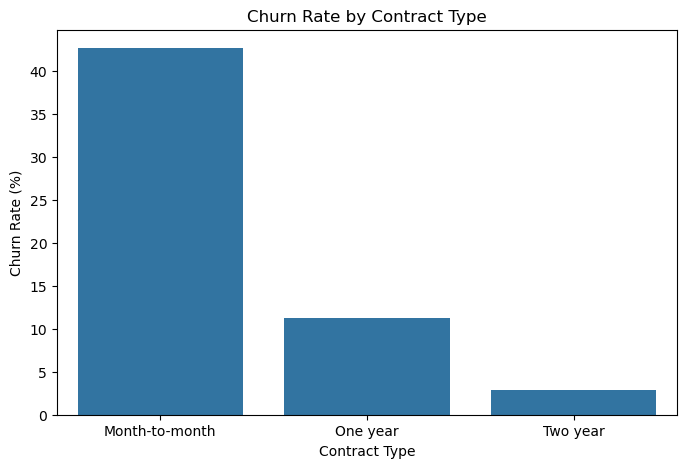

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

## 24. Churn Rate by Payment Method

We calculate the churn rate for each payment method to determine whether
certain payment methods are associated with higher customer churn.

In [31]:
payment_churn = (
    data.groupby("PaymentMethod")["Churn"]
    .mean()
    .sort_values(ascending=False) * 100
)

payment_churn

PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64

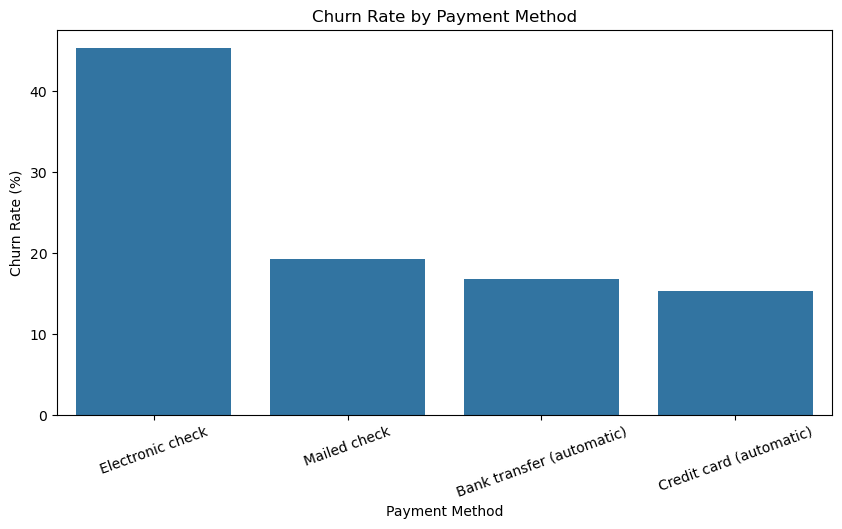

In [32]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()

## 25. Churn Rate by Internet Service

We compare churn rates across internet service categories to identify
whether the type of internet service is associated with customer retention.

In [33]:
internet_churn = (
    data.groupby("InternetService")["Churn"]
    .mean()
    .sort_values(ascending=False) * 100
)

internet_churn

InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn, dtype: float64

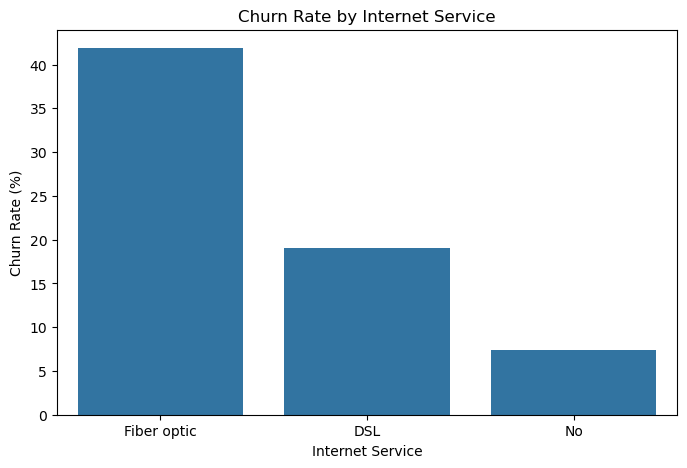

In [34]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

## 26. Churn Rate by Technical Support

We investigate whether customers with technical support have different
churn rates compared with customers without technical support.`

In [35]:
support_churn = (
    data.groupby("TechSupport")["Churn"]
    .mean()
    .sort_values(ascending=False) * 100
)

support_churn

TechSupport
No                     41.647465
Yes                    15.196078
No internet service     7.434211
Name: Churn, dtype: float64

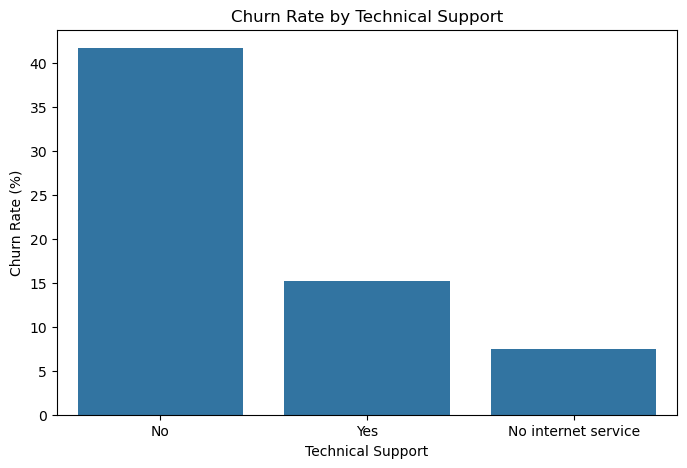

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=support_churn.index,
    y=support_churn.values
)

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Churn Rate (%)")

plt.show()

## 27. Average Tenure by Churn Status

We compare the average customer tenure between customers who stayed and
customers who churned.

This helps determine whether customer longevity is associated with churn.`

In [37]:
tenure_comparison = data.groupby("Churn")["tenure"].mean()

tenure_comparison

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

In [38]:
print(f"Average tenure of retained customers: {tenure_comparison[0]:.1f} months")
print(f"Average tenure of churned customers: {tenure_comparison[1]:.1f} months")

Average tenure of retained customers: 37.7 months
Average tenure of churned customers: 18.0 months


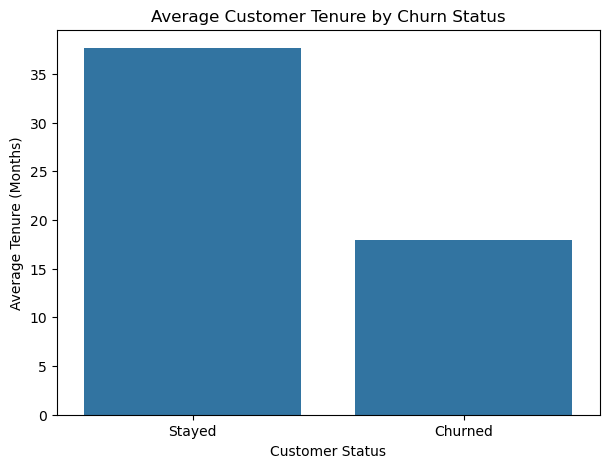

In [39]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=["Stayed", "Churned"],
    y=[tenure_comparison[0], tenure_comparison[1]]
)

plt.title("Average Customer Tenure by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Tenure (Months)")

plt.show()

## 28. Average Monthly Charges by Churn Status

We compare the average monthly charges of customers who stayed with those
who churned.

This can help identify whether higher monthly costs are associated with
customer churn.

In [40]:
monthly_charges_comparison = data.groupby("Churn")["MonthlyCharges"].mean()

print(f"Average monthly charge - Stayed: ${monthly_charges_comparison[0]:.2f}")
print(f"Average monthly charge - Churned: ${monthly_charges_comparison[1]:.2f}")

Average monthly charge - Stayed: $61.31
Average monthly charge - Churned: $74.44


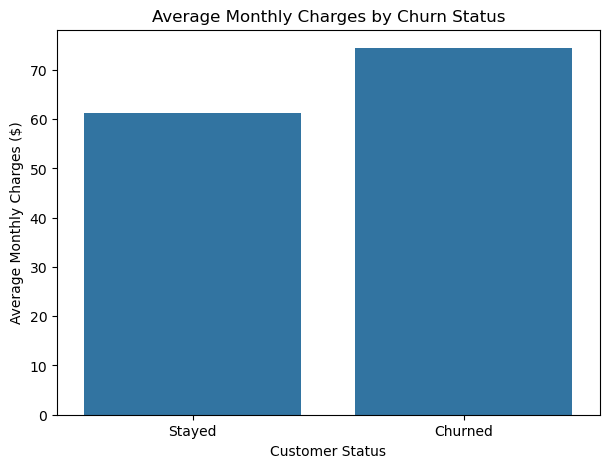

In [41]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=["Stayed", "Churned"],
    y=[monthly_charges_comparison[0], monthly_charges_comparison[1]]
)

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Monthly Charges ($)")

plt.show()

## 29. Correlation Analysis

Correlation measures the strength and direction of a relationship between
numerical variables.

A correlation value ranges from -1 to +1:

- +1 indicates a strong positive relationship.
- -1 indicates a strong negative relationship.
- 0 indicates little or no linear relationship.

We use a correlation heatmap to visualize relationships between numerical
variables.

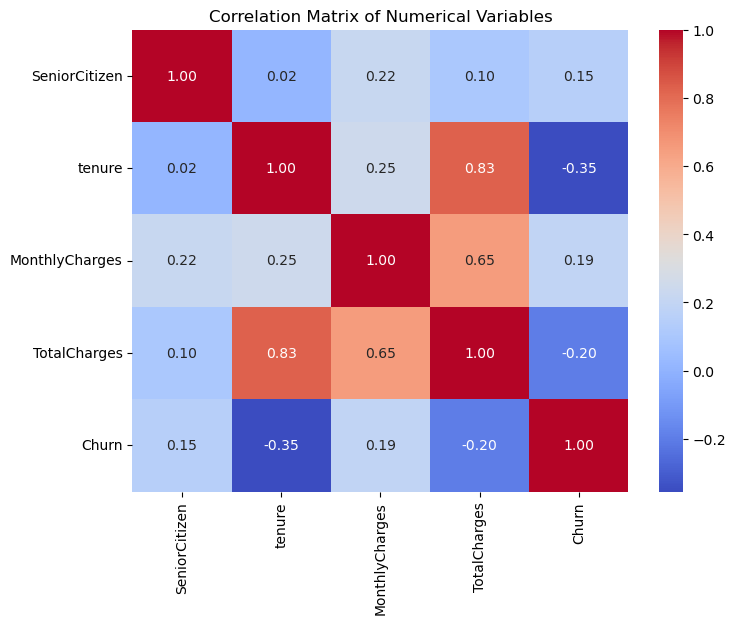

In [42]:
# Select numerical columns
numeric_data = data.select_dtypes(include=["int64", "float64"])

# Calculate correlations
correlation_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [43]:
# Correlation of numerical variables with Churn
churn_correlations = (
    correlation_matrix["Churn"]
    .sort_values(ascending=False)
)

churn_correlations

Churn             1.000000
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn, dtype: float64

## 30. Key EDA Findings

The following table summarizes selected customer characteristics and their
relationship with churn.

In [44]:
# Create a summary of key numerical metrics
eda_summary = pd.DataFrame({
    "Metric": [
        "Overall Churn Rate",
        "Average Tenure - Stayed",
        "Average Tenure - Churned",
        "Average Monthly Charges - Stayed",
        "Average Monthly Charges - Churned"
    ],
    "Value": [
        f"{churn_rate:.2f}%",
        f"{tenure_comparison[0]:.1f} months",
        f"{tenure_comparison[1]:.1f} months",
        f"${monthly_charges_comparison[0]:.2f}",
        f"${monthly_charges_comparison[1]:.2f}"
    ]
})

eda_summary

,Metric,Value
0,Overall Churn Rate,26.58%
1,Average Tenure - Stayed,37.7 months
2,Average Tenure - Churned,18.0 months
3,Average Monthly Charges - Stayed,$61.31
4,Average Monthly Charges - Churned,$74.44


## 31. Identifying Feature Types

Machine learning algorithms require numerical input.

Our dataset contains both numerical and categorical variables. We therefore
need to identify each type so that categorical variables can be appropriately
encoded before model training.

In [45]:
# Identify numerical and categorical columns
numerical_features = data.select_dtypes(include=["int64", "float64"]).columns
categorical_features = data.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 32. Separating Features and Target

The `Churn` column is our target variable.

We separate it from the remaining customer attributes:

- `X` contains the predictor variables.
- `y` contains the target variable.

The machine learning models will learn the relationship between `X` and `y`.

In [46]:
# Separate features and target
X = data.drop("Churn", axis=1)
y = data["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


## 33. Encoding Categorical Variables

The dataset contains categorical variables such as contract type,
payment method, and internet service.

Machine learning models require numerical input, so we use one-hot encoding
to convert categorical variables into binary numerical features.

For example:

Contract:

- Month-to-month
- One year
- Two year

can be represented using separate binary columns.

In [47]:
# Convert categorical variables into numerical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Display the transformed data
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [48]:
print("Original feature count:", X.shape[1])
print("Encoded feature count:", X_encoded.shape[1])

Original feature count: 19
Encoded feature count: 30


## 34. Train-Test Split

We divide the dataset into training and testing sets.

The training set is used to teach the machine learning models, while the
testing set is reserved for evaluating how well the models perform on
unseen data.

We use an 80/20 split.

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (5625, 30)
Testing features: (1407, 30)


In [50]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


## 35. Feature Scaling

Feature scaling transforms numerical variables so that they have a similar
scale.

This is particularly important for models such as Logistic Regression
because variables with very different ranges can influence the model
differently.

We use StandardScaler to standardize the features.

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [52]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nMissing values in training data:", np.isnan(X_train_scaled).sum())
print("Missing values in testing data:", np.isnan(X_test_scaled).sum())

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)

Missing values in training data: 0
Missing values in testing data: 0


## 36. Machine Learning Model Development

We will train three classification algorithms to predict customer churn:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Using multiple models allows us to compare their performance and select
the most suitable model for this business problem.

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 37. Logistic Regression

Logistic Regression is a classification algorithm used to predict the
probability of an observation belonging to a particular class.

In this project, it predicts the probability that a customer will churn.

The model outputs a probability between 0 and 1, which can then be converted
into a churn prediction.

In [54]:
# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [55]:
# Generate predictions
logistic_predictions = logistic_model.predict(X_test_scaled)

# Generate churn probabilities
logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## 38. Decision Tree Classifier

A Decision Tree makes predictions by creating a series of decision rules
based on the features in the dataset.

For example, the model may learn patterns such as:

Contract = Month-to-month
        ↓
Tenure < certain threshold
        ↓
Monthly Charges > certain threshold
        ↓
Higher probability of churn

In [56]:
# Create Decision Tree model
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [57]:
# Generate predictions
tree_predictions = decision_tree.predict(X_test)

# Generate churn probabilities
tree_probabilities = decision_tree.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated successfully.")

Decision Tree predictions generated successfully.


## 39. Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines
multiple decision trees.

Instead of relying on one decision tree, Random Forest builds many trees
and combines their predictions.

This often produces a more robust model than using a single decision tree.


In [58]:
# Create Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


In [59]:
# Generate predictions
forest_predictions = random_forest.predict(X_test)

# Generate churn probabilities
forest_probabilities = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


In [60]:
print("Logistic Regression predictions:", len(logistic_predictions))
print("Decision Tree predictions:", len(tree_predictions))
print("Random Forest predictions:", len(forest_predictions))
print("Actual test observations:", len(y_test))

Logistic Regression predictions: 1407
Decision Tree predictions: 1407
Random Forest predictions: 1407
Actual test observations: 1407


## 40. Model Evaluation

We evaluate each model using multiple performance metrics rather than
relying on accuracy alone.

The evaluation metrics used are:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

These metrics provide a broader view of model performance, particularly
because customer churn is a classification problem with an imbalanced target.

In [61]:
def evaluate_model(model_name, y_true, predictions, probabilities):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1 Score": f1_score(y_true, predictions),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }

In [62]:
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_predictions,
    logistic_probabilities
)

logistic_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8038379530916845,
 'Precision': 0.6475903614457831,
 'Recall': 0.5748663101604278,
 'F1 Score': 0.6090651558073654,
 'ROC-AUC': 0.8356727976766699}

In [63]:
tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    tree_predictions,
    tree_probabilities
)

tree_results

{'Model': 'Decision Tree',
 'Accuracy': 0.7782515991471215,
 'Precision': 0.5807291666666666,
 'Recall': 0.5962566844919787,
 'F1 Score': 0.5883905013192612,
 'ROC-AUC': 0.8195096572466881}

In [64]:
forest_results = evaluate_model(
    "Random Forest",
    y_test,
    forest_predictions,
    forest_probabilities
)

forest_results

{'Model': 'Random Forest',
 'Accuracy': 0.7910447761194029,
 'Precision': 0.6438848920863309,
 'Recall': 0.4786096256684492,
 'F1 Score': 0.549079754601227,
 'ROC-AUC': 0.838437187776633}

## 41. Model Performance Comparison

The performance of the three machine learning models is compared using
multiple evaluation metrics.

This allows us to identify the model that provides the best balance of
predictive performance for the customer churn problem.

In [65]:
results = pd.DataFrame([
    logistic_results,
    tree_results,
    forest_results
])

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803838,0.647590,0.574866,0.609065,0.835673
1,Decision Tree,0.778252,0.580729,0.596257,0.588391,0.819510
2,Random Forest,0.791045,0.643885,0.478610,0.549080,0.838437


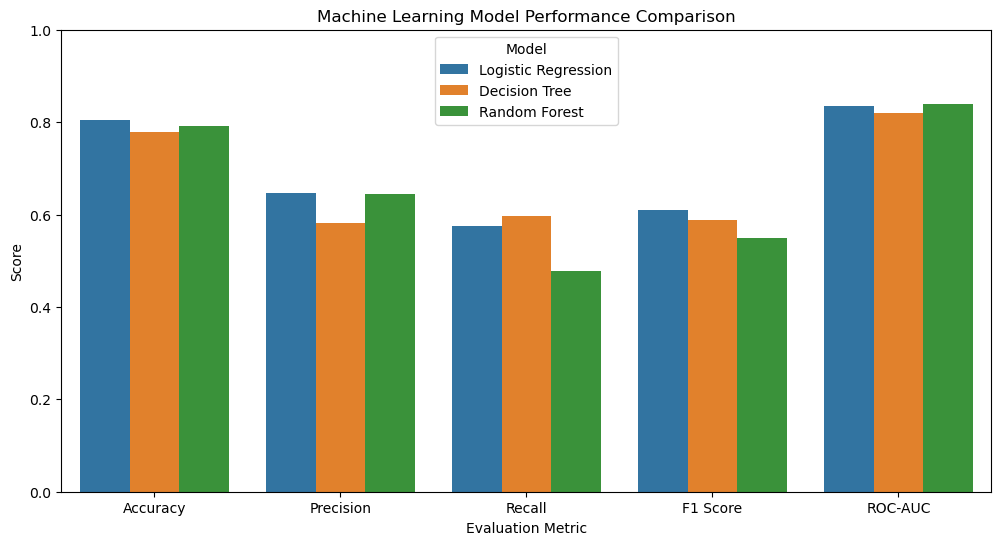

In [66]:
# Prepare data for visualization
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

results_melted = results.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.show()

In [67]:
best_model_row = results.loc[results["ROC-AUC"].idxmax()]

best_model_row

Model        Random Forest
Accuracy          0.791045
Precision         0.643885
Recall             0.47861
F1 Score           0.54908
ROC-AUC           0.838437
Name: 2, dtype: object

In [68]:
print("Best model based on ROC-AUC:")
print(best_model_row["Model"])

Best model based on ROC-AUC:
Random Forest


## 42. Hyperparameter Tuning

Machine learning models contain hyperparameters that control how the model
learns.

For Random Forest, examples include:

- Number of trees
- Maximum tree depth
- Minimum samples required for a split
- Minimum samples required at a leaf

We use GridSearchCV to test different combinations and identify a stronger
configuration based on cross-validation performance.

In [69]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 8, 12, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_base = RandomForestClassifier(
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")

Hyperparameter tuning completed.


In [70]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


In [71]:
best_rf = grid_search.best_estimator_

print("Best Random Forest model selected.")

Best Random Forest model selected.


In [72]:
tuned_predictions = best_rf.predict(X_test)

tuned_probabilities = best_rf.predict_proba(X_test)[:, 1]

print("Tuned model predictions generated.")

Tuned model predictions generated.


In [73]:
tuned_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    tuned_predictions,
    tuned_probabilities
)

tuned_results

{'Model': 'Tuned Random Forest',
 'Accuracy': 0.7889125799573561,
 'Precision': 0.64,
 'Recall': 0.47058823529411764,
 'F1 Score': 0.5423728813559322,
 'ROC-AUC': 0.8380877564437725}

In [74]:
rf_comparison = pd.DataFrame([
    forest_results,
    tuned_results
])

rf_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.791045,0.643885,0.478610,0.549080,0.838437
1,Tuned Random Forest,0.788913,0.640000,0.470588,0.542373,0.838088


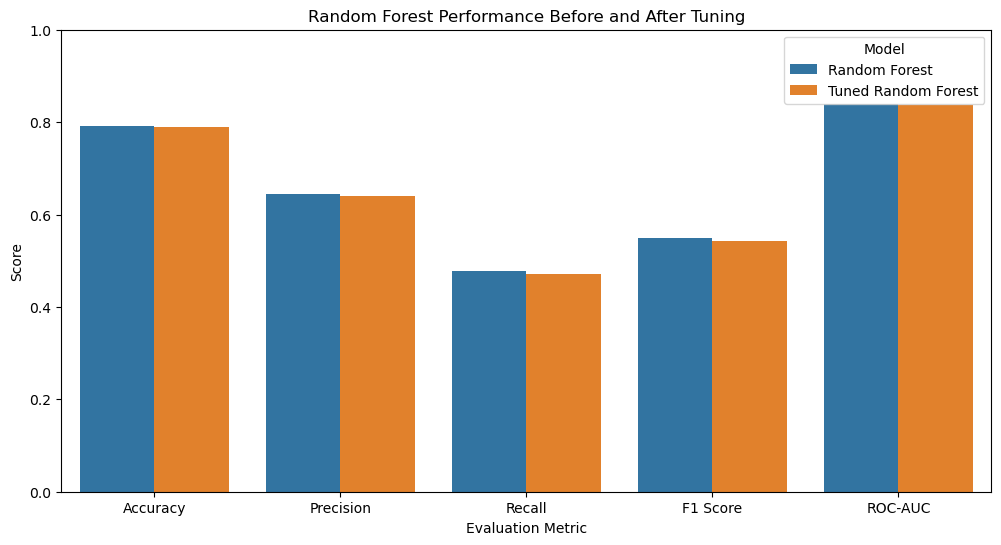

In [75]:
rf_comparison_melted = rf_comparison.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=rf_comparison_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Random Forest Performance Before and After Tuning")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.show()

## 43. Confusion Matrix

A confusion matrix shows how the classification model performed across the
two classes.

It contains four outcomes:

- True Negative (TN): Correctly predicted customers who stayed.
- True Positive (TP): Correctly predicted customers who churned.
- False Positive (FP): Predicted churn, but the customer stayed.
- False Negative (FN): Predicted that the customer would stay, but the
  customer actually churned.

For customer retention, false negatives are particularly important because
they represent customers who churned but were not identified by the model.

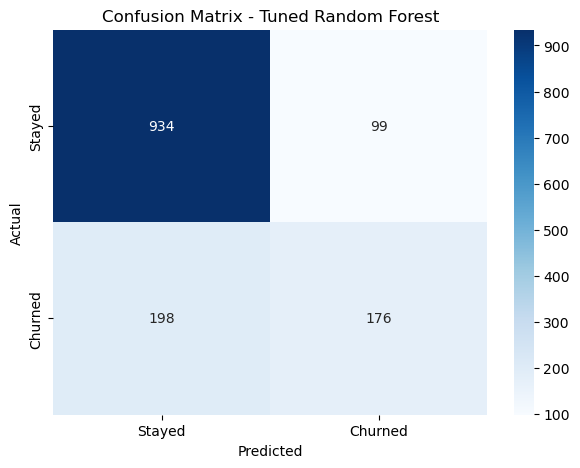

In [76]:
cm = confusion_matrix(y_test, tuned_predictions)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 44. Classification Report

The classification report provides precision, recall, and F1-score for
each class.

This gives us a more detailed understanding of how effectively the model
identifies both retained and churned customers.

In [77]:
print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=["Stayed", "Churned"]
    )
)

              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.86      1033
     Churned       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



## 45. ROC Curve

The Receiver Operating Characteristic (ROC) curve evaluates the model's
ability to distinguish between the two classes across different
classification thresholds.

The Area Under the Curve (ROC-AUC) summarizes this performance.

A higher ROC-AUC generally indicates better ability to distinguish between
customers who churn and customers who stay.

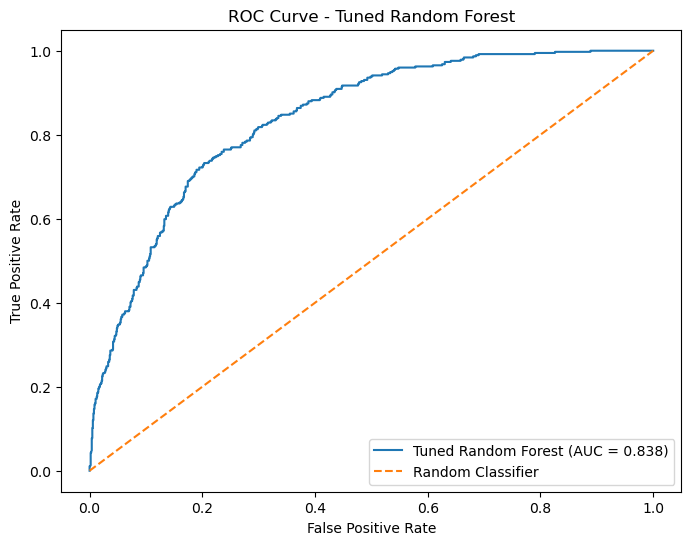

In [78]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    tuned_probabilities
)

auc_score = roc_auc_score(
    y_test,
    tuned_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Tuned Random Forest (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Tuned Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

## 46. Feature Importance

Feature importance shows which variables contributed most to the Random
Forest model's predictions.

Understanding important features helps translate the machine learning
results into actionable business insights.

In [79]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,tenure,0.209678
3,TotalCharges,0.130175
2,MonthlyCharges,0.089459
10,InternetService_Fiber optic,0.088213
25,Contract_Two year,0.076941
28,PaymentMethod_Electronic check,0.072804
13,OnlineSecurity_Yes,0.044165
24,Contract_One year,0.036977
19,TechSupport_Yes,0.027326
16,DeviceProtection_No internet service,0.023551


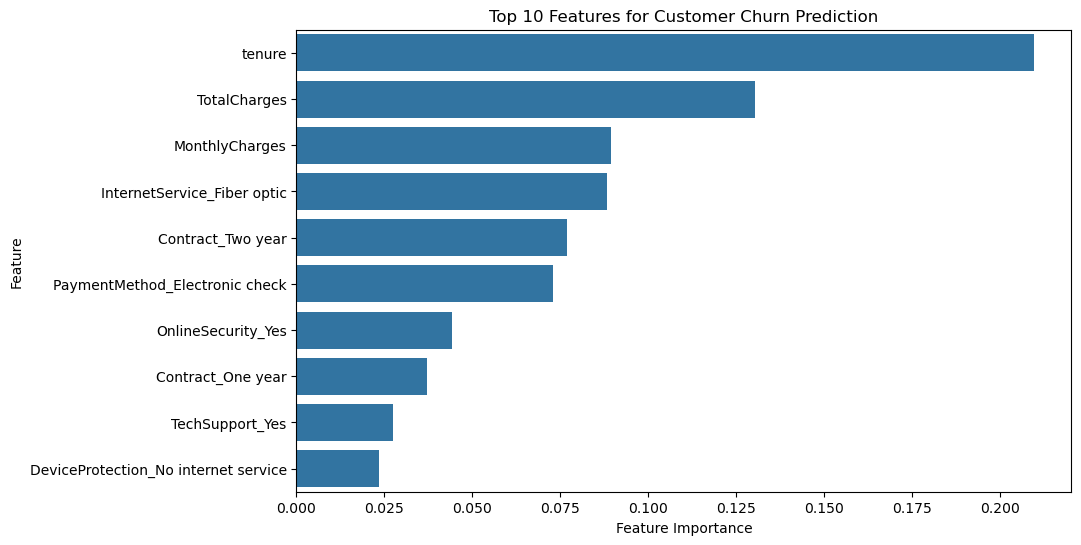

In [80]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features for Customer Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

## 47. Customer Churn Risk Prediction

The final model can estimate the probability that each customer will churn.

This allows the business to prioritize customers according to their
estimated churn risk rather than treating every customer equally.

In [81]:
# Create a prediction dataset
predictions_df = X_test.copy()

predictions_df["Actual_Churn"] = y_test.values
predictions_df["Churn_Probability"] = tuned_probabilities
predictions_df["Predicted_Churn"] = tuned_predictions

# Sort customers by predicted churn probability
predictions_df = predictions_df.sort_values(
    by="Churn_Probability",
    ascending=False
)

predictions_df.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Churn_Probability,Predicted_Churn
3380,1,1,95.10,95.10,True,True,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,1,0.867406,1
4585,1,1,85.05,85.05,False,False,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,1,0.848719,1
1731,1,1,69.60,69.60,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,1,0.829837,1
2607,1,1,69.75,69.75,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,1,0.823225,1
3159,1,3,94.85,335.75,True,False,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,0,0.817654,1
2927,0,1,69.90,69.90,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,0,0.817341,1
1739,0,1,69.90,69.90,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,1,0.817341,1
809,0,1,69.55,69.55,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,1,0.814297,1
2464,0,1,77.15,77.15,False,False,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,1,0.811894,1
2397,0,1,88.35,88.35,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,1,0.811411,1


## 48. Customer Risk Segmentation

To make the model's predictions easier to interpret from a business
perspective, customers are divided into three risk categories based on
their predicted probability of churn:

- Low Risk: below 40%
- Medium Risk: 40%–69%
- High Risk: 70% or higher

In [82]:
def assign_risk(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"


predictions_df["Risk_Level"] = (
    predictions_df["Churn_Probability"]
    .apply(assign_risk)
)

predictions_df["Risk_Level"].value_counts()

Risk_Level
Low Risk       1008
Medium Risk     319
High Risk        80
Name: count, dtype: int64

## 49. Final Model Performance

The tuned Random Forest model is evaluated using the key performance metrics
used throughout the project.

In [83]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_predictions),
    "Precision": precision_score(y_test, tuned_predictions),
    "Recall": recall_score(y_test, tuned_predictions),
    "F1 Score": f1_score(y_test, tuned_predictions),
    "ROC-AUC": roc_auc_score(y_test, tuned_probabilities)
}

final_metrics_df = pd.DataFrame(
    final_metrics.items(),
    columns=["Metric", "Score"]
)

final_metrics_df

,Metric,Score
0,Accuracy,0.788913
1,Precision,0.640000
2,Recall,0.470588
3,F1 Score,0.542373
4,ROC-AUC,0.838088


In [84]:
final_metrics_display = final_metrics_df.copy()

final_metrics_display["Score"] = (
    final_metrics_display["Score"] * 100
).round(2)

final_metrics_display

,Metric,Score
0,Accuracy,78.89
1,Precision,64.00
2,Recall,47.06
3,F1 Score,54.24
4,ROC-AUC,83.81


In [85]:
# Create a clean final model performance table
final_performance = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [
        accuracy_score(y_test, tuned_predictions),
        precision_score(y_test, tuned_predictions),
        recall_score(y_test, tuned_predictions),
        f1_score(y_test, tuned_predictions),
        roc_auc_score(y_test, tuned_probabilities)
    ]
})

final_performance["Score"] = (
    final_performance["Score"] * 100
).round(2)

final_performance

,Metric,Score
0,Accuracy,78.89
1,Precision,64.00
2,Recall,47.06
3,F1 Score,54.24
4,ROC-AUC,83.81


In [86]:
# Display the 10 most important features
top_10_features = (
    feature_importance
    .head(10)
    .reset_index(drop=True)
)

top_10_features

,Feature,Importance
0,tenure,0.209678
1,TotalCharges,0.130175
2,MonthlyCharges,0.089459
3,InternetService_Fiber optic,0.088213
4,Contract_Two year,0.076941
5,PaymentMethod_Electronic check,0.072804
6,OnlineSecurity_Yes,0.044165
7,Contract_One year,0.036977
8,TechSupport_Yes,0.027326
9,DeviceProtection_No internet service,0.023551


In [87]:
# Count customers in each risk category
risk_summary = (
    predictions_df["Risk_Level"]
    .value_counts()
    .rename_axis("Risk Level")
    .reset_index(name="Number of Customers")
)

risk_summary

,Risk Level,Number of Customers
0,Low Risk,1008
1,Medium Risk,319
2,High Risk,80


In [88]:
risk_summary["Percentage"] = (
    risk_summary["Number of Customers"]
    / risk_summary["Number of Customers"].sum()
    * 100
).round(2)

risk_summary

,Risk Level,Number of Customers,Percentage
0,Low Risk,1008,71.64
1,Medium Risk,319,22.67
2,High Risk,80,5.69


## Business Recommendations

Based on the exploratory analysis and machine learning results, the
following actions can support customer retention:

### 1. Prioritize High-Risk Customers

Customers with high predicted churn probabilities should receive
priority for proactive retention campaigns.

### 2. Focus on Contract Strategy

Customers on shorter-term contracts should be targeted with incentives
that encourage longer-term commitments.

### 3. Improve Customer Support

Customers without technical support or other support services should
be investigated to determine whether service limitations contribute to
higher churn.

### 4. Monitor Pricing and Monthly Charges

Customers with higher monthly charges should be monitored closely,
particularly when combined with other characteristics associated with
churn.

### 5. Use Predictive Risk Scoring

The churn probability generated by the machine learning model can be
incorporated into customer retention workflows so that resources can
be focused on customers with the highest estimated risk.

## Project Limitations

Although the model provides useful predictive insights, several
limitations should be considered:

- The dataset represents a specific telecommunications customer base
  and may not generalize to every company or market.
- Historical customer behavior does not guarantee future behavior.
- The model identifies statistical patterns and should not be interpreted
  as proof that a particular feature directly causes churn.
- Additional information such as customer satisfaction scores, complaint
  history, and interaction data could potentially improve future versions
  of the model.

## Technologies Used

- **Python** — Programming language
- **Pandas** — Data manipulation and analysis
- **NumPy** — Numerical computing
- **Matplotlib** — Data visualization
- **Seaborn** — Statistical visualization
- **Scikit-learn** — Machine learning
- **Jupyter Notebook** — Development environment

# 50. Conclusion

This project analyzed customer churn within a telecommunications dataset
and developed machine learning models to identify customers at risk of
leaving the company.

The analysis began with data cleaning and exploratory data analysis to
understand customer behavior and identify patterns associated with churn.

Three classification models were developed and compared:

- Logistic Regression
- Decision Tree
- Random Forest

The models were evaluated using accuracy, precision, recall, F1-score,
and ROC-AUC. Hyperparameter tuning was then applied to the Random Forest
model to improve its predictive performance.

Feature importance analysis provided additional insight into the customer
characteristics that contributed most strongly to churn predictions.

The final model can be used to identify customers with elevated churn
probabilities, allowing the business to prioritize retention efforts and
develop targeted customer engagement strategies.

Overall, this project demonstrates an end-to-end machine learning workflow,
from data preparation and exploratory analysis to predictive modeling,
model evaluation, and business-focused recommendations.